In [38]:
import os
import sys
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score
import scipy.stats as stats
import wfdb
import neurokit2 as nk
from joblib import Parallel, delayed
from tqdm import tqdm
import orjson
import pywt

In [39]:
# Add project root to sys.path
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))
from helper_code import *

# --- Utility Functions ---

In [40]:
def get_json(path):
    """Loads a JSON file."""
    with open(path, 'r') as f:
        return orjson.loads(f.read())

def load_ecg_data(exam_id, search_directory):
    """
    Searches for and loads ECG data (.mat and .hea files).
    """
    mat_filename = f"{exam_id}.mat"
    hea_filename = f"{exam_id}.hea"
    
    for dirpath, _, filenames in os.walk(search_directory):
        if mat_filename in filenames and hea_filename in filenames:
            mat_filepath = os.path.join(dirpath, mat_filename)
            hea_filepath = os.path.join(dirpath, hea_filename)
            try:
                data, header = load_challenge_data(hea_filepath)
                return data, header
            except Exception as e:
                print(f"Error loading {mat_filepath}: {e}")
                return None, None
    return None, None

# --- Feature Extraction ---

In [41]:
def extract_basic_features(record_path):
    """
    Extracts basic demographic and clinical features from the header file.
    """
    try:
        header = load_header(record_path + '.hea')
        age = get_age(header)
        is_male = 1 if get_sex(header) == 'Male' else 0
        chagas = get_label(header)
        return {'age': age, 'is_male': is_male, 'chagas': chagas}
    except Exception:
        return None

def extract_wavelet_features(record_path):
    """
    Extracts wavelet-based features from the ECG signal.
    """
    try:
        signals, _ = wfdb.rdsamp(record_path)
        ecg_signal = signals[:, 0]

        # Wavelet decomposition
        coeffs = pywt.wavedec(ecg_signal, 'db4', level=4)
        cA4, cD4, cD3, cD2, cD1 = coeffs

        features = {
            'wavelet_energy_d1': np.sum(np.square(cD1)),
            'wavelet_energy_d2': np.sum(np.square(cD2)),
            'wavelet_energy_d3': np.sum(np.square(cD3)),
            'wavelet_energy_d4': np.sum(np.square(cD4)),
            'wavelet_energy_a4': np.sum(np.square(cA4)),
            'wavelet_std_d1': np.std(cD1),
            'wavelet_std_d2': np.std(cD2),
            'wavelet_std_d3': np.std(cD3),
            'wavelet_std_d4': np.std(cD4),
            'wavelet_std_a4': np.std(cA4),
        }
        return features
    except Exception:
        return None



In [42]:
rr_intervals_list = []

In [43]:
def extract_advanced_ecg_features(signal, sampling_rate):
    """
    Extracts morphological and HRV features from a single ECG signal.
    Focuses on features robust for short recordings.
    """
    features = {}
    # Use Lead II for analysis, which is typically the second column in 12-lead ECGs
    if signal.ndim > 1 and signal.shape[1] > 1:
        lead_signal = signal[:, 1]
    else:
        lead_signal = signal.flatten()

    try:
        # Process the ECG signal with NeuroKit2
        signals, info = nk.ecg_process(lead_signal, sampling_rate=sampling_rate)
        peaks = info["ECG_R_Peaks"]

        # If not enough peaks are found, return empty features
        if len(peaks) < 4: # Need at least a few beats for meaningful stats
            return {}, []

        # --- Morphological Features (mean and std over all detected beats) ---
        morph_features = [
            'ECG_P_Duration', 'ECG_P_Amplitude', 'ECG_QRS_Duration', 
            'ECG_QRS_Amplitude', 'ECG_T_Duration', 'ECG_T_Amplitude', 'ECG_QT_Interval'
        ]
        for feature in morph_features:
            if feature in signals:
                feature_values = signals[feature].dropna()
                if not feature_values.empty:
                    features[f'{feature}_mean'] = feature_values.mean()
                    features[f'{feature}_std'] = feature_values.std()
                else: # Handle case where no valid values exist for a feature
                    features[f'{feature}_mean'] = np.nan
                    features[f'{feature}_std'] = np.nan

        # --- HRV Features (computed only if enough peaks are detected) ---
        # Based on user feedback, these calculations can fail on very short signals.
        # We will only compute them if more than 20 RR intervals (21 peaks) are found.
        if len(peaks) > 20:
            try:
                # Add a check for variability in peaks to prevent errors
                if np.std(np.diff(peaks)) > 0:
                    # Time-Domain
                    hrv_time = nk.hrv_time(peaks, sampling_rate=sampling_rate, show=False)
                    features['HRV_RMSSD'] = hrv_time['HRV_RMSSD'].iloc[0]
                    features['HRV_MeanNN'] = hrv_time['HRV_MeanNN'].iloc[0]
                    features['HRV_pNN50'] = hrv_time['HRV_pNN50'].iloc[0]

                    # Non-Linear (Poincaré)
                    hrv_poincare_df = nk.hrv_poincare(peaks, sampling_rate=sampling_rate, show=False)
                    features['HRV_SD1'] = hrv_poincare_df['HRV_SD1'].iloc[0]
                else:
                    raise ValueError("No variability in RR-intervals.")
            except Exception:
                features['HRV_RMSSD'] = np.nan
                features['HRV_MeanNN'] = np.nan
                features['HRV_pNN50'] = np.nan
                features['HRV_SD1'] = np.nan
        else:
            # If not enough peaks, fill with NaN
            features['HRV_RMSSD'] = np.nan
            features['HRV_MeanNN'] = np.nan
            features['HRV_pNN50'] = np.nan
            features['HRV_SD1'] = np.nan

        # --- Overall Heart Rate ---
        if 'ECG_Rate' in signals and not signals['ECG_Rate'].dropna().empty:
            features['Heart_Rate_Mean'] = signals['ECG_Rate'].mean()
        else:
            features['Heart_Rate_Mean'] = np.nan
        
        rr_interval_lengths = [len(peaks)]

    except Exception as e:
        # Silently fail for signals that are too noisy or short to be processed
        return {}, []

    return features, rr_interval_lengths

In [44]:
def process_record(record_path):
    """
    Main processing function for a single record.
    """
    try:
        # Basic features from header
        basic_features = extract_basic_features(record_path)
        if not basic_features:
            return None, []

        # Load signal for advanced feature extraction
        signal, fields = wfdb.rdsamp(record_path)
        sampling_rate = fields['fs']
        
        if signal is None or signal.size == 0:
            return None, []

        # Advanced and wavelet features
        advanced_features, rr_interval_lengths = extract_advanced_ecg_features(signal, sampling_rate)
        wavelet_features = extract_wavelet_features(record_path)

        # Combine all features
        all_features = basic_features
        if advanced_features:
            all_features.update(advanced_features)
        if wavelet_features:
            all_features.update(wavelet_features)
        
        all_features['record'] = os.path.basename(record_path)
        return all_features, rr_interval_lengths
    except Exception as e:
        # print(f"Error in process_record for {os.path.basename(record_path)}: {e}") # Uncomment for debugging
        return None, []

# --- Main Execution ---

In [45]:
# --- Data Loading (from xgboost_training.ipynb) ---
data_dir = '../training_data/samitrop/'
print(os.getcwd())
print(f"Searching for .hea files in: {data_dir}")

hea_files = glob.glob(os.path.join(data_dir, '**', '*.hea'), recursive=True)
record_stems = [f[:-4] for f in hea_files]
print(f"Found {len(record_stems)} records to process.")

# --- Feature Extraction (with new wavelet features) ---
all_rr_interval_lengths_collected = []
processed_results = []

with Parallel(n_jobs=-1) as parallel:
    # Correctly unpack the tuple returned by process_record
    for res, rr_lengths in tqdm(parallel(delayed(process_record)(record) for record in record_stems), total=len(record_stems)):
        if res is not None:
            processed_results.append(res)
            if rr_lengths:
                all_rr_interval_lengths_collected.extend(rr_lengths)

df = pd.DataFrame(processed_results)

/Users/andysmithwick/Documents/GitHub/physionet2025/EDA
Searching for .hea files in: ../training_data/samitrop/
Found 815 records to process.


/Users/andysmithwick/Documents/GitHub/physionet2025/venv/lib/python3.11/site-packages/neurokit2/signal/signal_fixpeaks.py:307: RuntimeWarning: divide by zero encountered in divide
  mrrs /= th2
/Users/andysmithwick/Documents/GitHub/physionet2025/venv/lib/python3.11/site-packages/neurokit2/signal/signal_fixpeaks.py:307: RuntimeWarning: invalid value encountered in divide
  mrrs /= th2
/Users/andysmithwick/Documents/GitHub/physionet2025/venv/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/andysmithwick/Documents/GitHub/physionet2025/venv/lib/python3.11/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/andysmithwick/Documents/GitHub/physionet2025/venv/lib/python3.11/site-packages/neurokit2/signal/signal_period.py:84: NeuroKitWarning: Too few peaks detected to compute the rate. Returning 

In [46]:
np.mean(rr_intervals_list)

/Users/andysmithwick/Documents/GitHub/physionet2025/venv/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/andysmithwick/Documents/GitHub/physionet2025/venv/lib/python3.11/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


np.float64(nan)

# --- EDA (from notebook_template.ipynb) ---

In [47]:
df

,age,is_male,chagas,HRV_RMSSD,HRV_MeanNN,HRV_pNN50,HRV_SD1,Heart_Rate_Mean,wavelet_energy_d1,wavelet_energy_d2,wavelet_energy_d3,wavelet_energy_d4,wavelet_energy_a4,wavelet_std_d1,wavelet_std_d2,wavelet_std_d3,wavelet_std_d4,wavelet_std_a4,record
0,57.0,0,1,NaN,NaN,NaN,NaN,75.675724,0.023059,0.177760,4.739077,28.521508,15588.265507,0.003340,0.013123,0.095648,0.329868,2.931356,289472
1,43.0,0,1,NaN,NaN,NaN,NaN,65.218058,0.034713,0.181650,2.882752,7.507623,66.983660,0.004859,0.015682,0.088026,0.197556,0.595307,149836
2,91.0,0,1,NaN,NaN,NaN,NaN,49.620062,0.024125,0.211502,4.099856,29.403777,383.290804,0.003430,0.014337,0.088964,0.334990,0.972537,285512
3,71.0,0,1,NaN,NaN,NaN,NaN,84.192766,0.058749,0.521482,10.568348,53.606304,2891.509594,0.005351,0.022504,0.142835,0.452311,2.961366,504525
4,48.0,0,1,NaN,NaN,NaN,NaN,59.585032,0.026955,0.128980,0.794518,6.564846,18.109465,0.004282,0.013212,0.046214,0.186370,0.309516,103042
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
810,44.0,1,1,NaN,NaN,NaN,NaN,62.972409,0.048463,0.534993,10.263346,14.588346,52.672814,0.005742,0.026919,0.166095,0.277738,0.527873,740339
811,60.0,0,1,NaN,NaN,NaN,NaN,83.393268,0.075085,1.024988,28.228448,78.111423,191.630758,0.007147,0.037266,0.275453,0.642244,1.006434,673081
812,67.0,0,1,NaN,NaN,NaN,NaN,65.782620,0.018560,0.348942,11.774266,55.101608,3012.207278,0.003005,0.018411,0.150765,0.458338,0.800420,458531
813,45.0,1,1,NaN,NaN,NaN,NaN,85.207822,0.020205,0.085693,2.041636,8.410864,763.253916,0.003142,0.009139,0.062902,0.179514,0.752397,341213


In [48]:
# Data Cleaning
df.dropna(subset=['chagas'], inplace=True)
df.fillna(df.median(numeric_only=True), inplace=True)

print("Feature extraction complete.")
print(f"Dataset shape: {df.shape}")
print("Columns:", df.columns.tolist())

Feature extraction complete.
Dataset shape: (815, 19)
Columns: ['age', 'is_male', 'chagas', 'HRV_RMSSD', 'HRV_MeanNN', 'HRV_pNN50', 'HRV_SD1', 'Heart_Rate_Mean', 'wavelet_energy_d1', 'wavelet_energy_d2', 'wavelet_energy_d3', 'wavelet_energy_d4', 'wavelet_energy_a4', 'wavelet_std_d1', 'wavelet_std_d2', 'wavelet_std_d3', 'wavelet_std_d4', 'wavelet_std_a4', 'record']


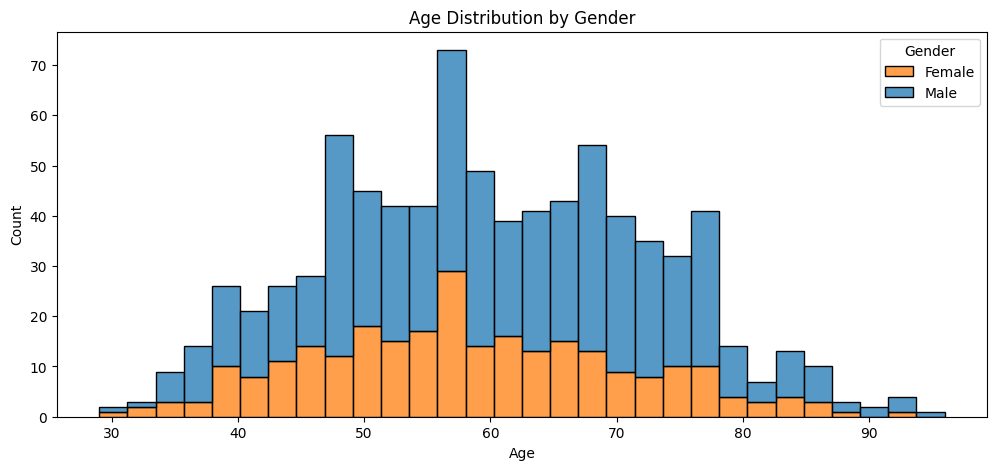

In [49]:
# 1. Feature Distribution Analysis
plt.figure(figsize=(12, 5))
sns.histplot(data=df, x='age', hue='is_male', multiple='stack', bins=30)
plt.title('Age Distribution by Gender')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend(title='Gender', labels=['Female', 'Male'])
plt.savefig('age_distribution.png')
plt.show()

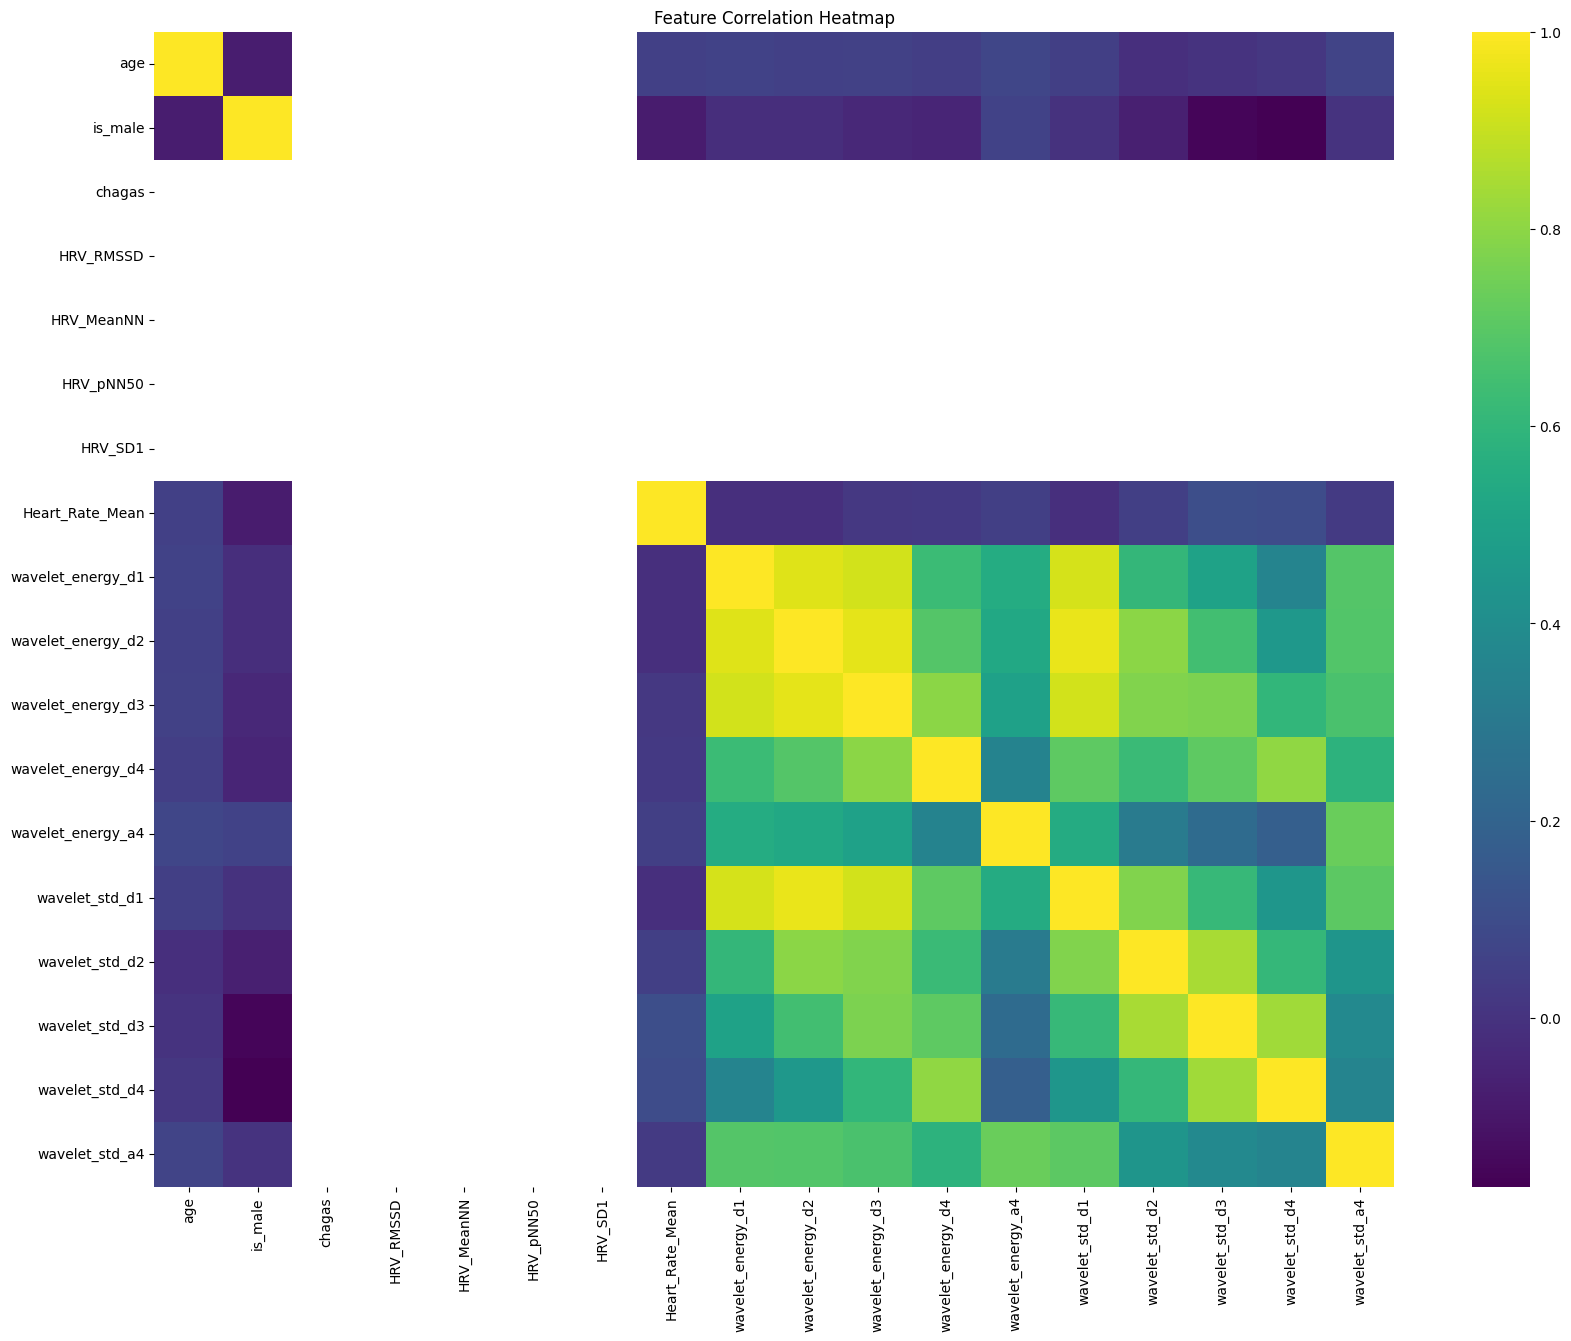

In [50]:
# 2. Correlation Heatmap
plt.figure(figsize=(20, 15))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=False, cmap='viridis')
plt.title('Feature Correlation Heatmap')
plt.savefig('correlation_heatmap.png')
plt.show()

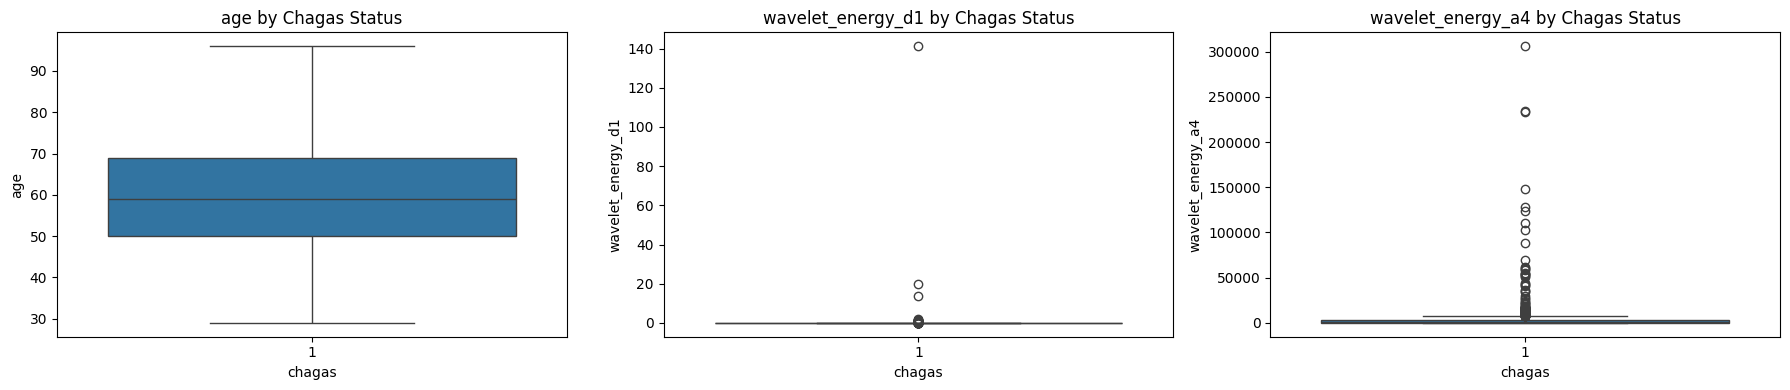

In [51]:
# 3. Boxplots for key features
key_features = ['age', 'wavelet_energy_d1', 'wavelet_energy_a4']

plt.figure(figsize=(18, 4))
for i, feature in enumerate(key_features):
    if feature in df.columns:
        plt.subplot(1, 3, i + 1)
        sns.boxplot(x='chagas', y=feature, data=df)
        plt.title(f'{feature} by Chagas Status')
plt.tight_layout()
plt.savefig('feature_boxplots.png')
plt.show()

In [52]:
# Save the processed data
df.to_csv('combined_features.csv', index=False)
print("EDA plots and processed data saved in the EDA folder.")

EDA plots and processed data saved in the EDA folder.
